# 🚀 CUSTOMER INTELLIGENCE 360

## Executive Analytics Capstone
### Customer Churn, Segmentation, Risk & Retention Intelligence

---

### Project Objective

This capstone combines the complete customer analytics workflow
developed across Tasks 02, 03, and 04.

The project transforms customer-level data into an executive
decision-support system covering:

📌 Data Quality  
📌 Customer Behaviour  
📌 Business KPIs  
📌 Churn Drivers  
📌 Customer Segmentation  
📌 Churn Risk  
📌 Revenue Exposure  
📌 Retention Recommendations  

---

### Analytics Journey

Raw Customer Data
        ↓
Data Quality & EDA
        ↓
Business KPIs
        ↓
Churn Driver Analysis
        ↓
Customer Segmentation
        ↓
Explainable Risk Scoring
        ↓
Revenue Risk Analysis
        ↓
Retention Recommendations
        ↓
Executive Decision Support

---

### Important Note

The dataset used in this project is small and synthetic.

Therefore, the findings are intended for analytical demonstration
and should not be interpreted as statistically validated
production predictions.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

from IPython.display import display

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving customer_churn_task04_results.csv to customer_churn_task04_results.csv


In [3]:
df = pd.read_csv("customer_churn_task04_results.csv")

print("Dataset Shape:", df.shape)

df

Dataset Shape: (15, 18)


,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn,TenureGroup,Segment,SegmentName,RiskScore,RiskCategory,RiskFactors,Recommendation
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes,0-12 months,2,High Engagement / High Support,8,High Risk,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No,13-24 months,2,High Engagement / High Support,1,Low Risk,No major risk factors,Continue regular customer engagement
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes,0-12 months,0,Established Customers,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No,25-36 months,1,New / Low Engagement,1,Low Risk,High monthly charges,Review plan value and consider a better-value ...
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes,0-12 months,2,High Engagement / High Support,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
5,CUST-1006,Male,31,18,Basic,49.99,899.82,One Year,2,UPI,No,13-24 months,2,High Engagement / High Support,2,Low Risk,Higher-risk payment method,Offer alternative or more convenient payment o...
6,CUST-1007,Female,23,3,Basic,49.99,149.97,Month-to-Month,6,Credit Card,Yes,0-12 months,0,Established Customers,8,High Risk,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
7,CUST-1008,Male,60,48,Enterprise,149.99,7199.52,Two Year,1,Bank Transfer,No,37+ months,1,New / Low Engagement,1,Low Risk,High monthly charges,Review plan value and consider a better-value ...
8,CUST-1009,Female,38,15,Pro,79.99,1199.85,One Year,2,Credit Card,No,13-24 months,2,High Engagement / High Support,1,Low Risk,No major risk factors,Continue regular customer engagement
9,CUST-1010,Male,27,4,Basic,49.99,199.96,Month-to-Month,4,UPI,Yes,0-12 months,0,Established Customers,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...


In [4]:
df.head()

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn,TenureGroup,Segment,SegmentName,RiskScore,RiskCategory,RiskFactors,Recommendation
0,CUST-1001,Female,34,12,Basic,49.99,599.88,Month-to-Month,3,Credit Card,Yes,0-12 months,2,High Engagement / High Support,8,High Risk,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
1,CUST-1002,Male,45,24,Pro,79.99,1919.76,One Year,1,Bank Transfer,No,13-24 months,2,High Engagement / High Support,1,Low Risk,No major risk factors,Continue regular customer engagement
2,CUST-1003,Female,29,6,Basic,49.99,299.94,Month-to-Month,5,UPI,Yes,0-12 months,0,Established Customers,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
3,CUST-1004,Male,52,36,Enterprise,149.99,5399.64,Two Year,0,Credit Card,No,25-36 months,1,New / Low Engagement,1,Low Risk,High monthly charges,Review plan value and consider a better-value ...
4,CUST-1005,Female,41,8,Pro,79.99,639.92,Month-to-Month,4,Debit Card,Yes,0-12 months,2,High Engagement / High Support,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...


In [5]:
df.tail()

,CustomerID,Gender,Age,TenureMonths,SubscriptionType,MonthlyCharges,TotalCharges,ContractType,SupportTickets,PaymentMethod,Churn,TenureGroup,Segment,SegmentName,RiskScore,RiskCategory,RiskFactors,Recommendation
10,CUST-1011,Female,49,30,Enterprise,149.99,4499.70,Two Year,0,Credit Card,No,25-36 months,1,New / Low Engagement,1,Low Risk,High monthly charges,Review plan value and consider a better-value ...
11,CUST-1012,Male,33,14,Pro,79.99,1119.86,Month-to-Month,3,Debit Card,Yes,13-24 months,2,High Engagement / High Support,7,High Risk,"High support tickets, Higher-risk payment method",Contact customer and resolve support issues | ...
12,CUST-1013,Female,55,22,Basic,49.99,1099.78,One Year,1,Bank Transfer,No,13-24 months,2,High Engagement / High Support,1,Low Risk,No major risk factors,Continue regular customer engagement
13,CUST-1014,Male,26,2,Basic,49.99,99.98,Month-to-Month,5,UPI,Yes,0-12 months,0,Established Customers,9,High Risk,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
14,CUST-1015,Female,43,40,Enterprise,149.99,5999.60,Two Year,1,Credit Card,No,37+ months,1,New / Low Engagement,1,Low Risk,High monthly charges,Review plan value and consider a better-value ...


In [6]:
print("=" * 60)
print("DATA HEALTH CHECK")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDuplicate Customer IDs:")
print(df["CustomerID"].duplicated().sum())

print("\nData Types:")
print(df.dtypes)

DATA HEALTH CHECK

Dataset Shape:
(15, 18)

Missing Values:
0

Duplicate Rows:
0

Duplicate Customer IDs:
0

Data Types:
CustomerID           object
Gender               object
Age                   int64
TenureMonths          int64
SubscriptionType     object
MonthlyCharges      float64
TotalCharges        float64
ContractType         object
SupportTickets        int64
PaymentMethod        object
Churn                object
TenureGroup          object
Segment               int64
SegmentName          object
RiskScore             int64
RiskCategory         object
RiskFactors          object
Recommendation       object
dtype: object


In [7]:
numeric_columns = [
    "Age",
    "TenureMonths",
    "MonthlyCharges",
    "TotalCharges",
    "SupportTickets"
]

df[numeric_columns].describe().round(2)

,Age,TenureMonths,MonthlyCharges,TotalCharges,SupportTickets
count,15.00,15.00,15.00,15.00,15.00
mean,39.07,18.80,84.66,2088.48,2.53
std,11.39,14.33,42.74,2407.37,1.92
min,23.00,2.00,49.99,99.98,0.00
25%,30.00,7.00,49.99,449.91,1.00
50%,38.00,15.00,79.99,1099.78,2.00
75%,47.00,27.00,114.99,3209.73,4.00
max,60.00,48.00,149.99,7199.52,6.00


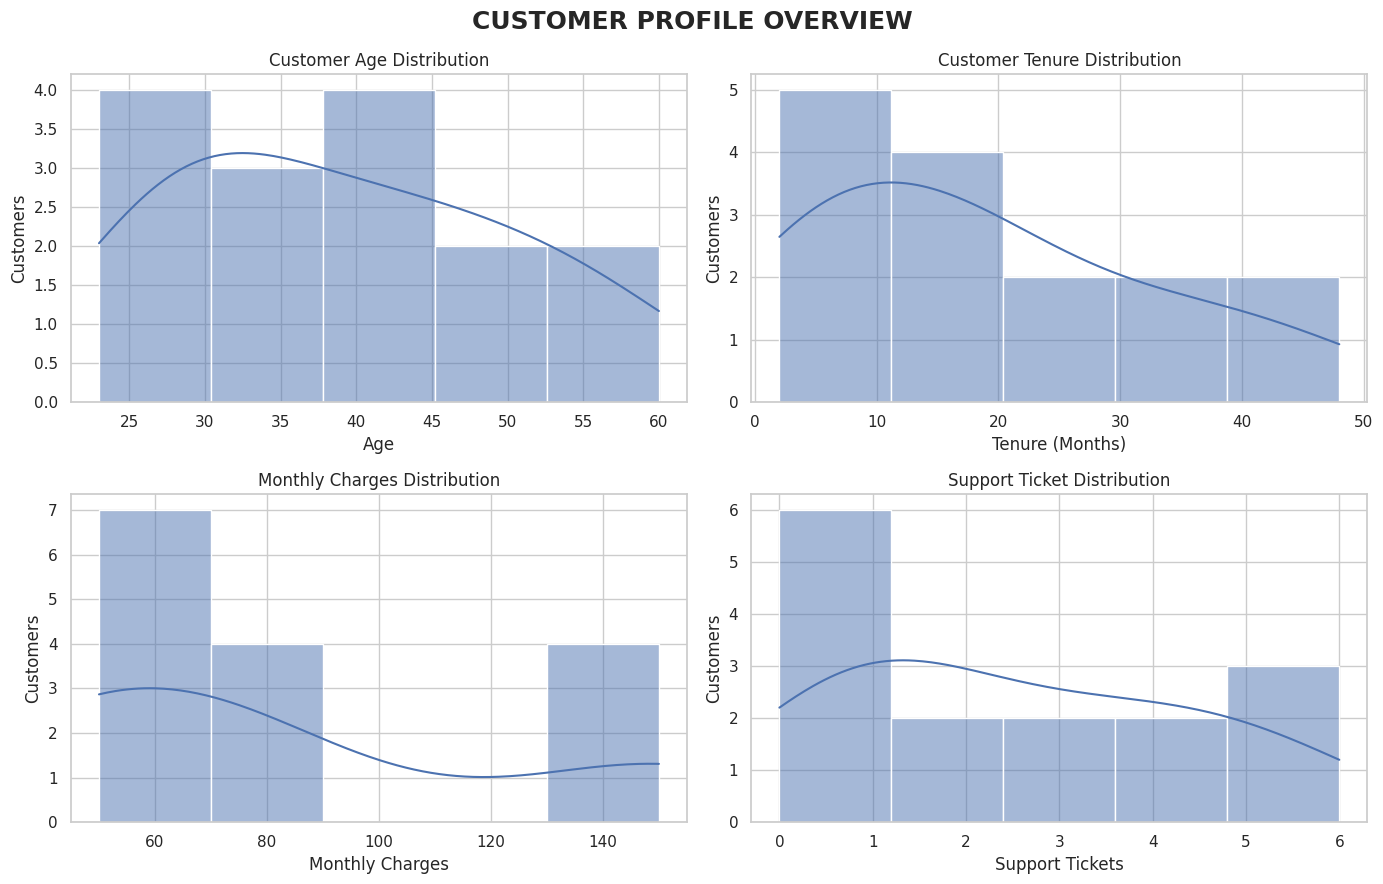

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.histplot(
    df["Age"],
    kde=True,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Customer Age Distribution")
axes[0, 0].set_xlabel("Age")
axes[0, 0].set_ylabel("Customers")


sns.histplot(
    df["TenureMonths"],
    kde=True,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Customer Tenure Distribution")
axes[0, 1].set_xlabel("Tenure (Months)")
axes[0, 1].set_ylabel("Customers")


sns.histplot(
    df["MonthlyCharges"],
    kde=True,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Monthly Charges Distribution")
axes[1, 0].set_xlabel("Monthly Charges")
axes[1, 0].set_ylabel("Customers")


sns.histplot(
    df["SupportTickets"],
    kde=True,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Support Ticket Distribution")
axes[1, 1].set_xlabel("Support Tickets")
axes[1, 1].set_ylabel("Customers")

plt.suptitle(
    "CUSTOMER PROFILE OVERVIEW",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

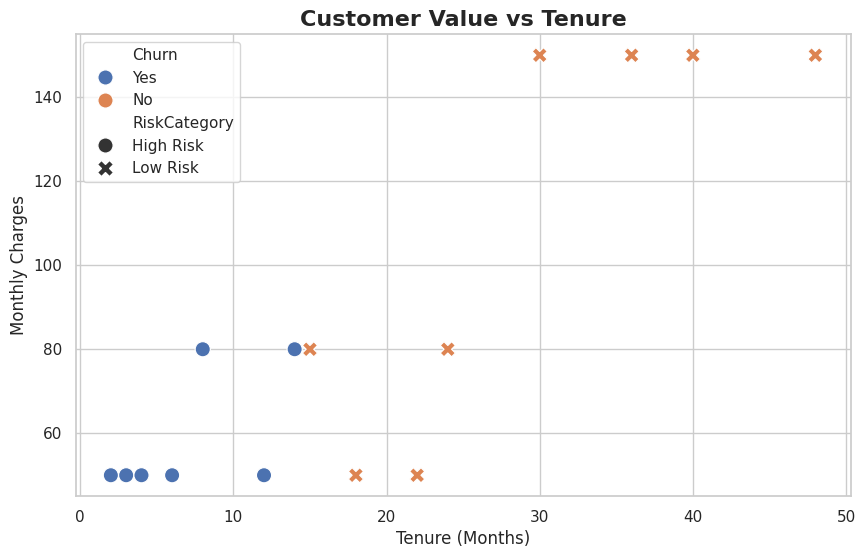

In [9]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="TenureMonths",
    y="MonthlyCharges",
    hue="Churn",
    style="RiskCategory",
    s=120
)

plt.title(
    "Customer Value vs Tenure",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Monthly Charges")

plt.show()

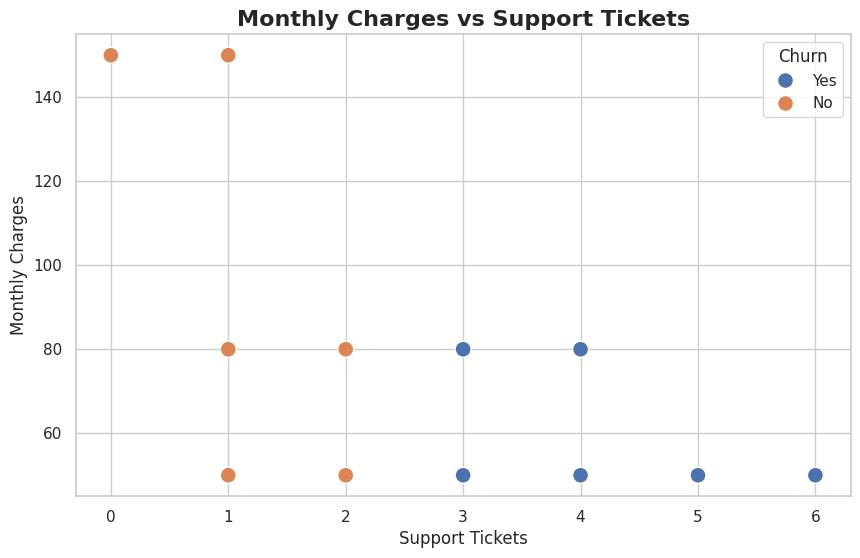

In [10]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="SupportTickets",
    y="MonthlyCharges",
    hue="Churn",
    s=130
)

plt.title(
    "Monthly Charges vs Support Tickets",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Support Tickets")
plt.ylabel("Monthly Charges")

plt.show()

In [11]:
total_customers = len(df)

churned_customers = (
    df["Churn"] == "Yes"
).sum()

retained_customers = (
    df["Churn"] == "No"
).sum()

churn_rate = (
    churned_customers / total_customers
) * 100

retention_rate = (
    retained_customers / total_customers
) * 100

total_monthly_revenue = (
    df["MonthlyCharges"].sum()
)

revenue_at_risk = (
    df.loc[
        df["Churn"] == "Yes",
        "MonthlyCharges"
    ].sum()
)

revenue_at_risk_percentage = (
    revenue_at_risk /
    total_monthly_revenue
) * 100

average_monthly_charge = (
    df["MonthlyCharges"].mean()
)

average_tenure = (
    df["TenureMonths"].mean()
)

high_risk_customers = (
    df["RiskCategory"] == "High Risk"
).sum()

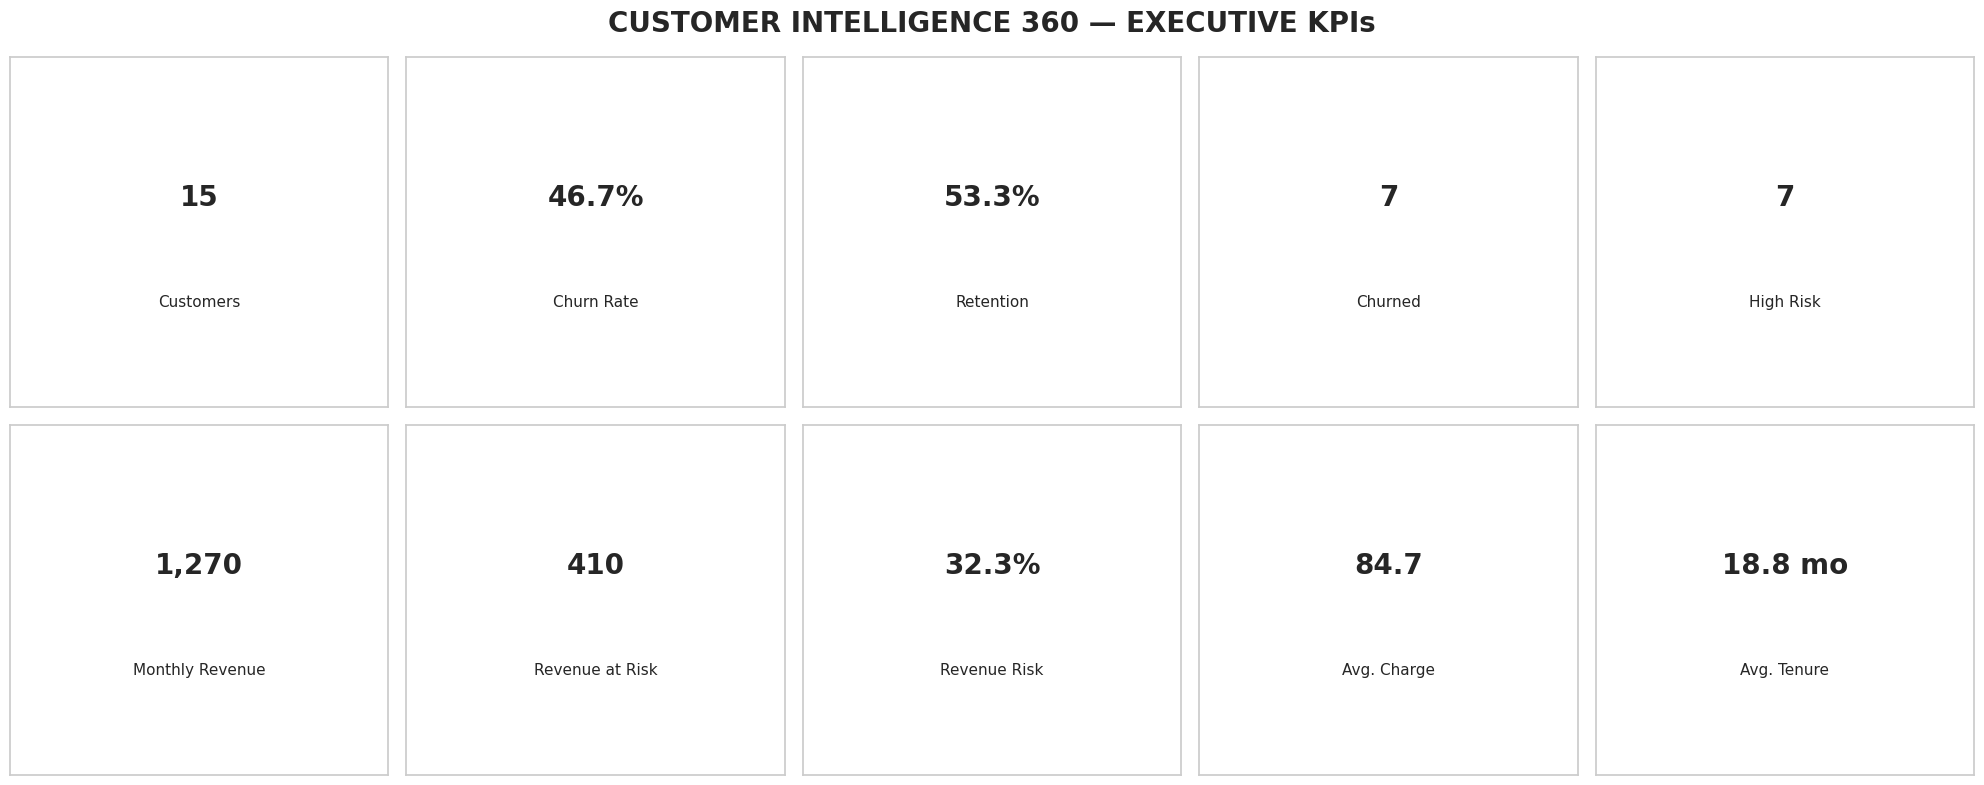

In [12]:
fig, axes = plt.subplots(
    2, 5,
    figsize=(20, 8)
)

kpis = [
    ("Customers", f"{total_customers}"),
    ("Churn Rate", f"{churn_rate:.1f}%"),
    ("Retention", f"{retention_rate:.1f}%"),
    ("Churned", f"{churned_customers}"),
    ("High Risk", f"{high_risk_customers}"),
    ("Monthly Revenue", f"{total_monthly_revenue:,.0f}"),
    ("Revenue at Risk", f"{revenue_at_risk:,.0f}"),
    ("Revenue Risk", f"{revenue_at_risk_percentage:.1f}%"),
    ("Avg. Charge", f"{average_monthly_charge:.1f}"),
    ("Avg. Tenure", f"{average_tenure:.1f} mo")
]

for ax, (title, value) in zip(
    axes.flatten(),
    kpis
):

    ax.text(
        0.5,
        0.60,
        value,
        ha="center",
        va="center",
        fontsize=20,
        fontweight="bold"
    )

    ax.text(
        0.5,
        0.30,
        title,
        ha="center",
        va="center",
        fontsize=11
    )

    ax.set_xticks([])
    ax.set_yticks([])

    for spine in ax.spines.values():
        spine.set_visible(True)

plt.suptitle(
    "CUSTOMER INTELLIGENCE 360 — EXECUTIVE KPIs",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [13]:
funnel_data = pd.DataFrame({
    "Stage": [
        "Total Customers",
        "Retained Customers",
        "Churned Customers"
    ],
    "Customers": [
        total_customers,
        retained_customers,
        churned_customers
    ]
})

funnel_data

,Stage,Customers
0,Total Customers,15
1,Retained Customers,8
2,Churned Customers,7


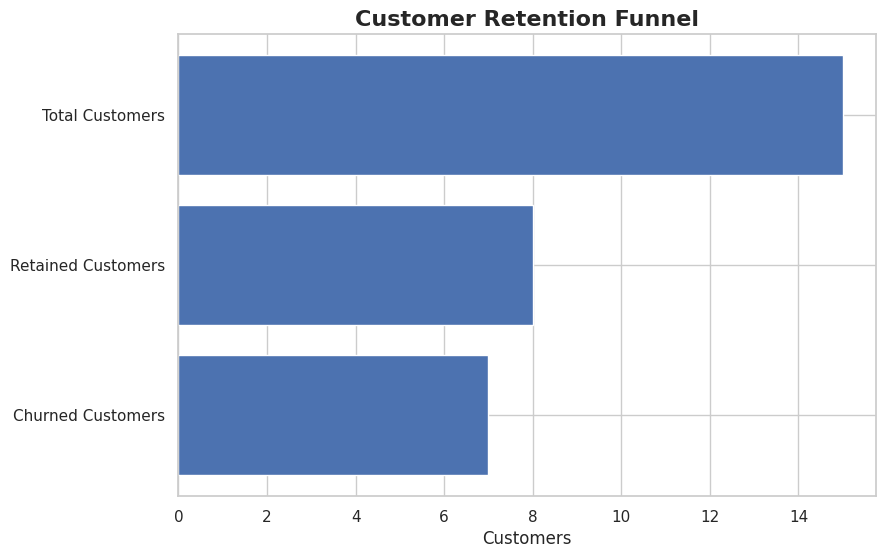

In [14]:
plt.figure(figsize=(9, 6))

plt.barh(
    funnel_data["Stage"],
    funnel_data["Customers"]
)

plt.title(
    "Customer Retention Funnel",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customers")

plt.gca().invert_yaxis()

plt.show()

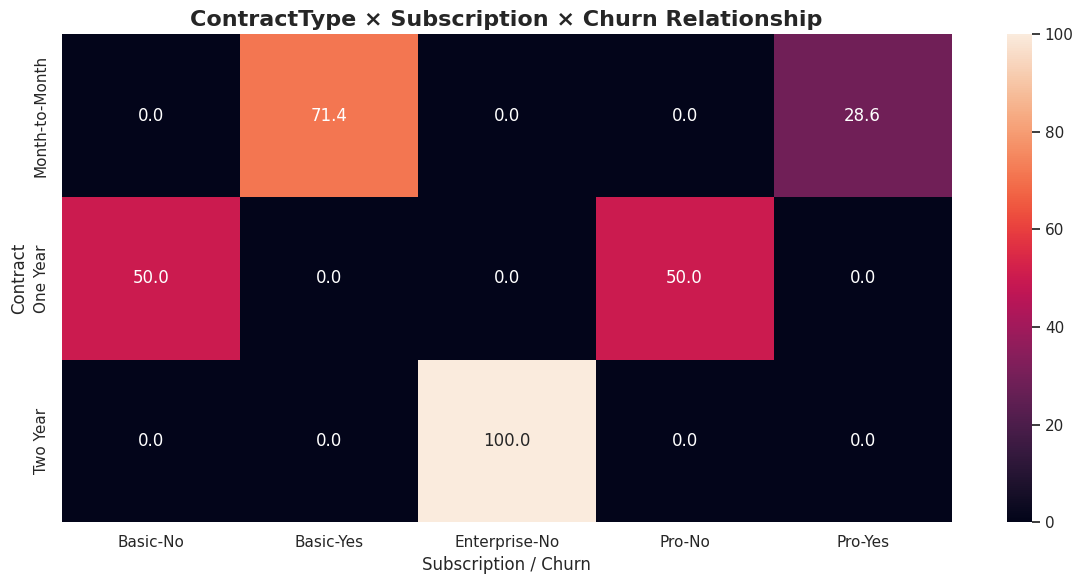

In [16]:
heatmap_data = pd.crosstab(
    df["ContractType"],
    [
        df["SubscriptionType"],
        df["Churn"]
    ],
    normalize="index"
) * 100

plt.figure(figsize=(12, 6))

sns.heatmap(
    heatmap_data.round(1),
    annot=True,
    fmt=".1f"
)

plt.title(
    "ContractType × Subscription × Churn Relationship",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Subscription / Churn")
plt.ylabel("Contract")

plt.tight_layout()
plt.show()

In [19]:
contract_churn = (
    df.groupby("ContractType")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

payment_churn = (
    df.groupby("PaymentMethod")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

subscription_churn = (
    df.groupby("SubscriptionType")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

tenure_churn = (
    df.groupby(
        "TenureGroup",
        observed=False
    )["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
)

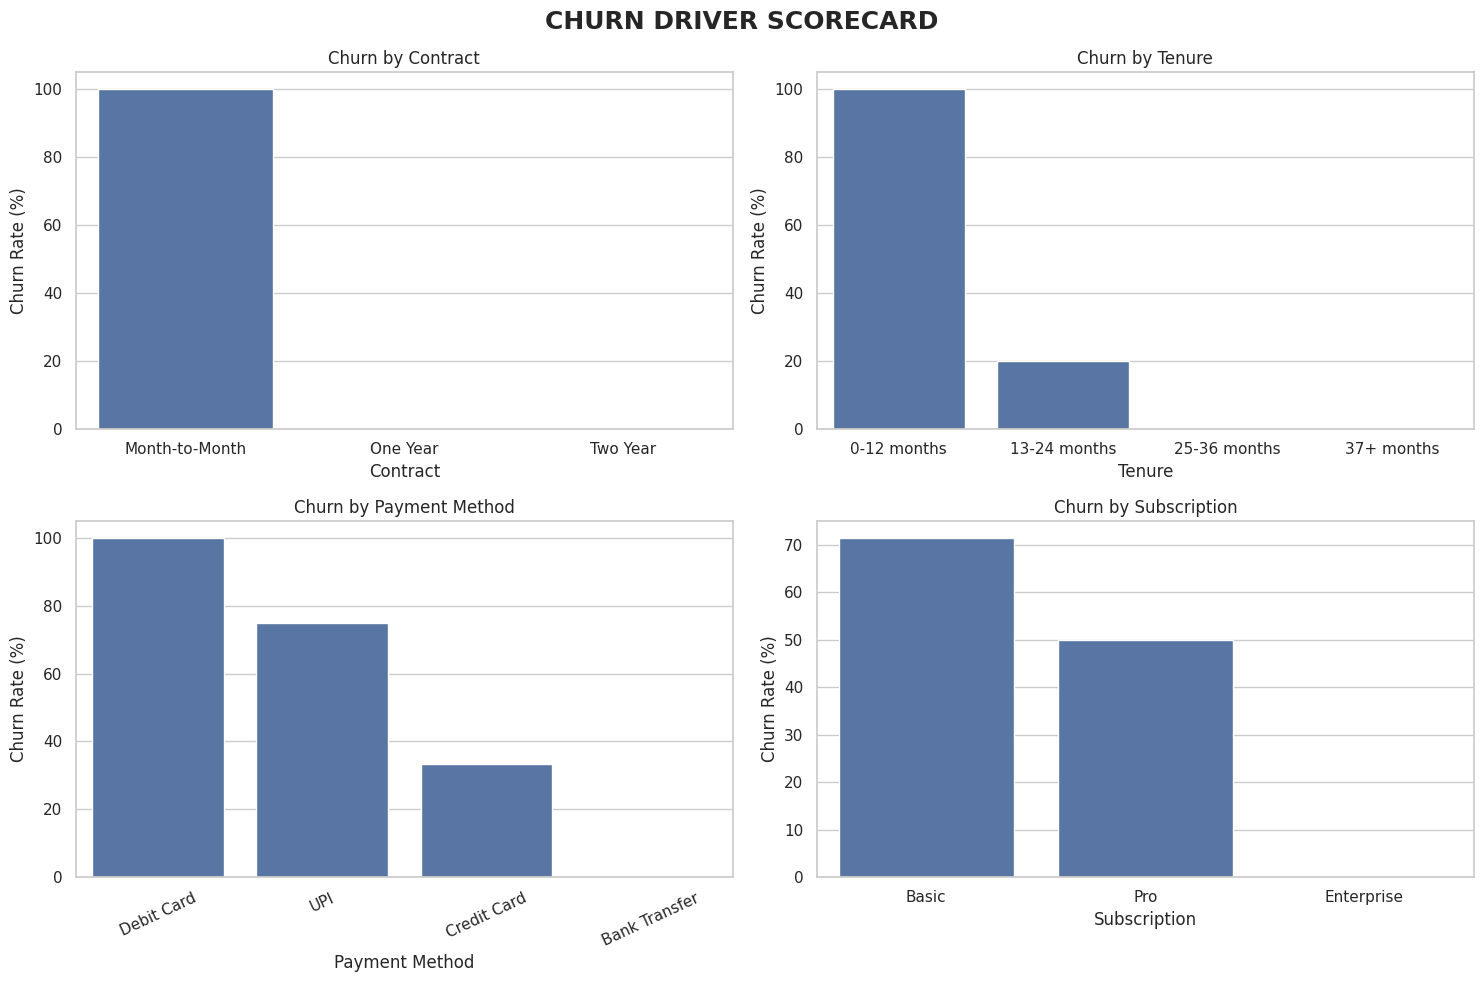

In [20]:
fig, axes = plt.subplots(
    2, 2,
    figsize=(15, 10)
)

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Churn by Contract")
axes[0, 0].set_ylabel("Churn Rate (%)")
axes[0, 0].set_xlabel("Contract")


sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Churn by Tenure")
axes[0, 1].set_ylabel("Churn Rate (%)")
axes[0, 1].set_xlabel("Tenure")


sns.barplot(
    x=payment_churn.index,
    y=payment_churn.values,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Churn by Payment Method")
axes[1, 0].set_ylabel("Churn Rate (%)")
axes[1, 0].set_xlabel("Payment Method")

axes[1, 0].tick_params(axis="x", rotation=25)


sns.barplot(
    x=subscription_churn.index,
    y=subscription_churn.values,
    ax=axes[1, 1]
)

axes[1, 1].set_title("Churn by Subscription")
axes[1, 1].set_ylabel("Churn Rate (%)")
axes[1, 1].set_xlabel("Subscription")

plt.suptitle(
    "CHURN DRIVER SCORECARD",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [21]:
revenue_matrix = pd.pivot_table(
    df,
    values="MonthlyCharges",
    index="RiskCategory",
    columns="Churn",
    aggfunc="sum",
    fill_value=0
)

revenue_matrix

Churn,No,Yes
RiskCategory,,
High Risk,0.00,409.93
Low Risk,859.92,0.00


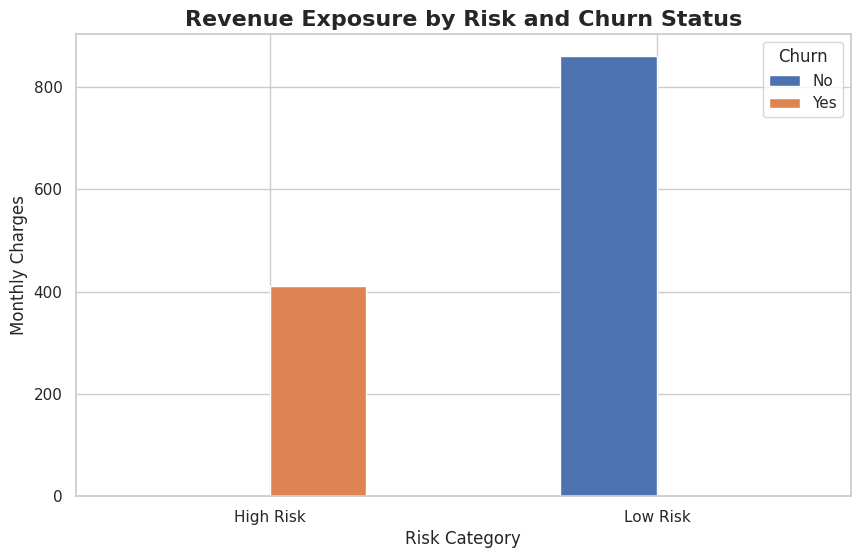

In [22]:
revenue_matrix.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Revenue Exposure by Risk and Churn Status",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Risk Category")
plt.ylabel("Monthly Charges")

plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

In [23]:
segment_profile = df.groupby(
    "SegmentName"
).agg(
    Customers=("CustomerID", "count"),
    AvgAge=("Age", "mean"),
    AvgTenure=("TenureMonths", "mean"),
    AvgMonthlyCharges=("MonthlyCharges", "mean"),
    AvgSupportTickets=("SupportTickets", "mean"),
    ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100),
    AvgRiskScore=("RiskScore", "mean")
).round(2)

segment_profile

,Customers,AvgAge,AvgTenure,AvgMonthlyCharges,AvgSupportTickets,ChurnRate,AvgRiskScore
SegmentName,,,,,,,
Established Customers,4,26.25,3.75,49.99,5.00,100.00,8.75
High Engagement / High Support,7,39.57,16.14,67.13,2.29,42.86,4.14
New / Low Engagement,4,51.00,38.50,149.99,0.50,0.00,1.00


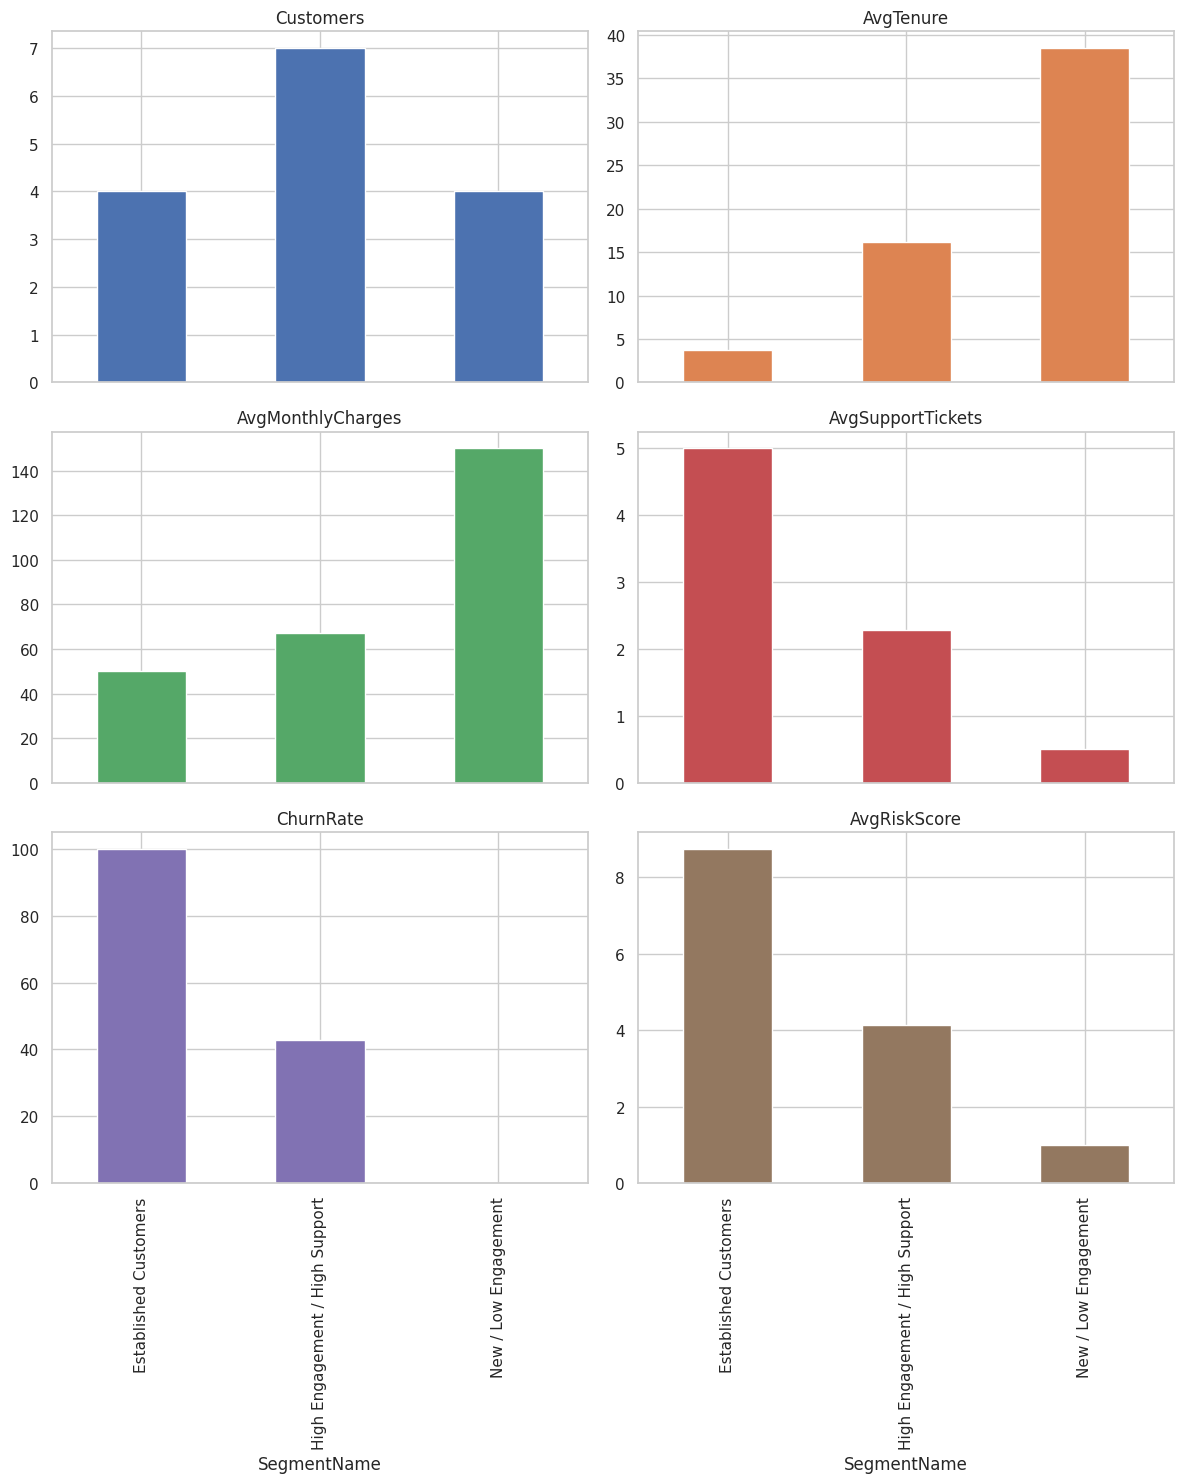

In [24]:
segment_profile[[
    "Customers",
    "AvgTenure",
    "AvgMonthlyCharges",
    "AvgSupportTickets",
    "ChurnRate",
    "AvgRiskScore"
]].plot(
    kind="bar",
    subplots=True,
    figsize=(12, 15),
    layout=(3, 2),
    legend=False
)

plt.tight_layout()
plt.show()

In [25]:
risk_summary = df.groupby(
    "RiskCategory"
).agg(
    Customers=("CustomerID", "count"),
    AvgRiskScore=("RiskScore", "mean"),
    MonthlyRevenue=("MonthlyCharges", "sum"),
    Churned=("Churn", lambda x: (x == "Yes").sum())
).reindex([
    "Low Risk",
    "Medium Risk",
    "High Risk"
])

risk_summary.round(2)

,Customers,AvgRiskScore,MonthlyRevenue,Churned
RiskCategory,,,,
Low Risk,8.0,1.12,859.92,0.0
Medium Risk,NaN,NaN,NaN,NaN
High Risk,7.0,8.43,409.93,7.0


In [26]:
risk_churn = pd.crosstab(
    df["RiskCategory"],
    df["Churn"],
    normalize="index"
) * 100

risk_churn.round(2)

Churn,No,Yes
RiskCategory,,
High Risk,0.0,100.0
Low Risk,100.0,0.0


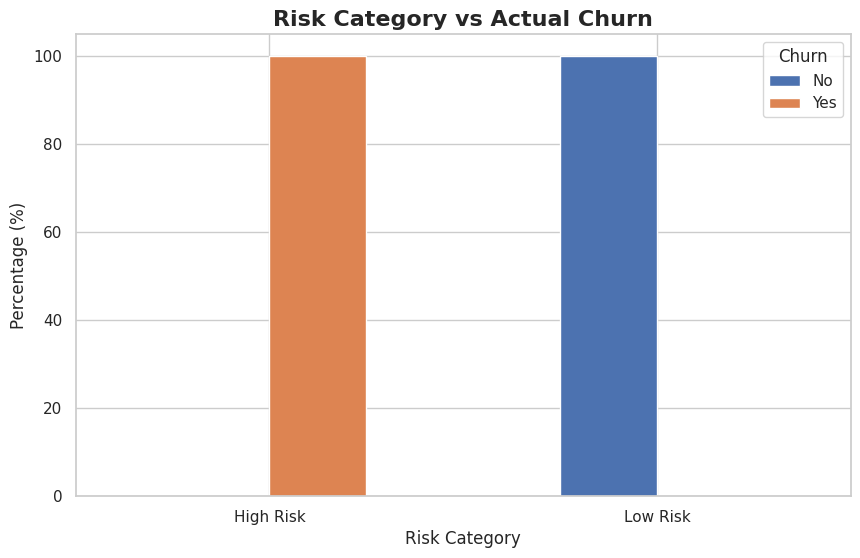

In [27]:
risk_churn.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title(
    "Risk Category vs Actual Churn",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Risk Category")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.legend(title="Churn")

plt.show()

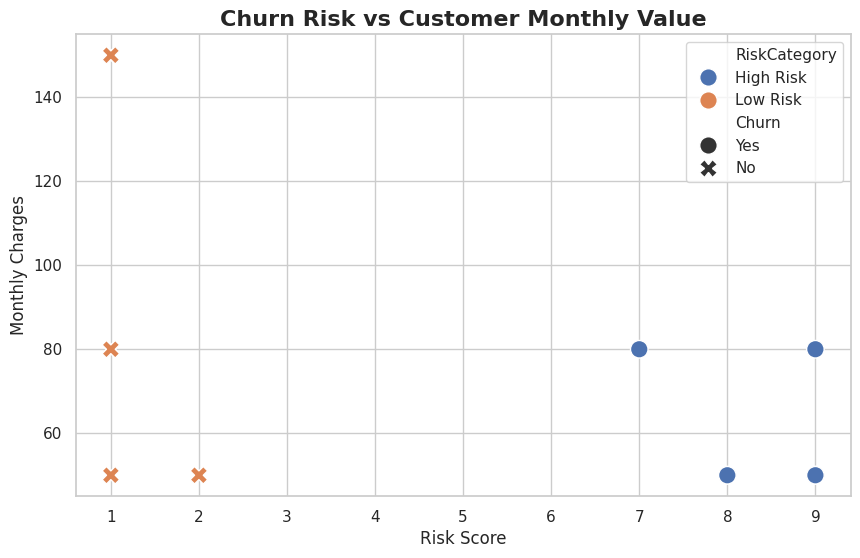

In [28]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="RiskScore",
    y="MonthlyCharges",
    hue="RiskCategory",
    style="Churn",
    s=160
)

plt.title(
    "Churn Risk vs Customer Monthly Value",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Risk Score")
plt.ylabel("Monthly Charges")

plt.show()

In [29]:
df["PriorityScore"] = (
    df["RiskScore"] *
    df["MonthlyCharges"]
)

df["PriorityRank"] = (
    df["PriorityScore"]
    .rank(
        ascending=False,
        method="dense"
    )
    .astype(int)
)

priority_columns = [
    "CustomerID",
    "SegmentName",
    "RiskCategory",
    "RiskScore",
    "MonthlyCharges",
    "PriorityScore",
    "PriorityRank",
    "RiskFactors",
    "Recommendation"
]

priority_table = (
    df[priority_columns]
    .sort_values("PriorityRank")
)

priority_table

,CustomerID,SegmentName,RiskCategory,RiskScore,MonthlyCharges,PriorityScore,PriorityRank,RiskFactors,Recommendation
4,CUST-1005,High Engagement / High Support,High Risk,9,79.99,719.91,1,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
11,CUST-1012,High Engagement / High Support,High Risk,7,79.99,559.93,2,"High support tickets, Higher-risk payment method",Contact customer and resolve support issues | ...
9,CUST-1010,Established Customers,High Risk,9,49.99,449.91,3,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
2,CUST-1003,Established Customers,High Risk,9,49.99,449.91,3,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
13,CUST-1014,Established Customers,High Risk,9,49.99,449.91,3,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
6,CUST-1007,Established Customers,High Risk,8,49.99,399.92,4,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
0,CUST-1001,High Engagement / High Support,High Risk,8,49.99,399.92,4,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
7,CUST-1008,New / Low Engagement,Low Risk,1,149.99,149.99,5,High monthly charges,Review plan value and consider a better-value ...
14,CUST-1015,New / Low Engagement,Low Risk,1,149.99,149.99,5,High monthly charges,Review plan value and consider a better-value ...
10,CUST-1011,New / Low Engagement,Low Risk,1,149.99,149.99,5,High monthly charges,Review plan value and consider a better-value ...


In [30]:
top_retention_opportunities = (
    priority_table
    .head(10)
)

top_retention_opportunities

,CustomerID,SegmentName,RiskCategory,RiskScore,MonthlyCharges,PriorityScore,PriorityRank,RiskFactors,Recommendation
4,CUST-1005,High Engagement / High Support,High Risk,9,79.99,719.91,1,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
11,CUST-1012,High Engagement / High Support,High Risk,7,79.99,559.93,2,"High support tickets, Higher-risk payment method",Contact customer and resolve support issues | ...
9,CUST-1010,Established Customers,High Risk,9,49.99,449.91,3,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
2,CUST-1003,Established Customers,High Risk,9,49.99,449.91,3,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
13,CUST-1014,Established Customers,High Risk,9,49.99,449.91,3,"Short tenure, High support tickets, Higher-ris...",Provide onboarding and early engagement suppor...
6,CUST-1007,Established Customers,High Risk,8,49.99,399.92,4,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
0,CUST-1001,High Engagement / High Support,High Risk,8,49.99,399.92,4,"Short tenure, High support tickets",Provide onboarding and early engagement suppor...
7,CUST-1008,New / Low Engagement,Low Risk,1,149.99,149.99,5,High monthly charges,Review plan value and consider a better-value ...
14,CUST-1015,New / Low Engagement,Low Risk,1,149.99,149.99,5,High monthly charges,Review plan value and consider a better-value ...
10,CUST-1011,New / Low Engagement,Low Risk,1,149.99,149.99,5,High monthly charges,Review plan value and consider a better-value ...


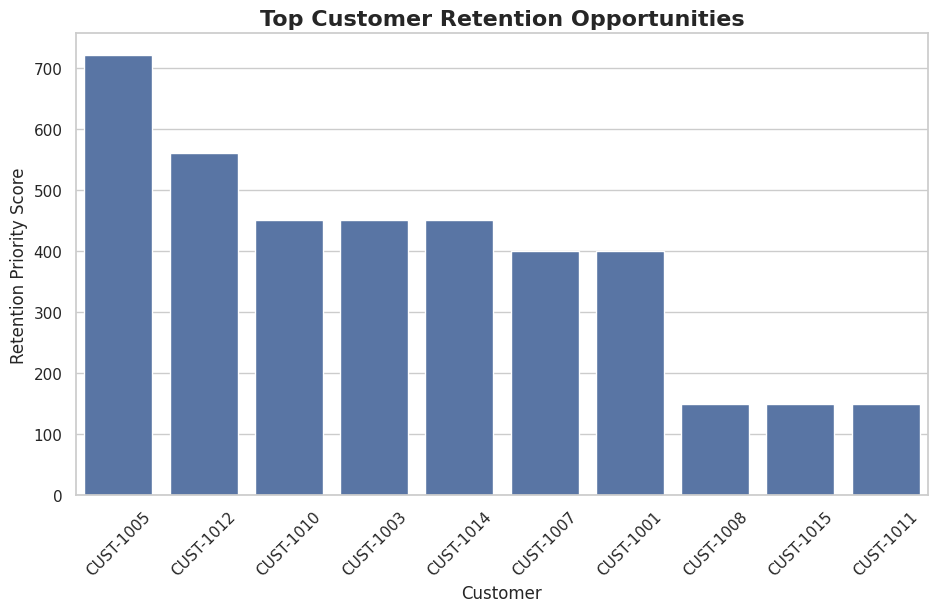

In [31]:
top10 = priority_table.head(10).copy()

plt.figure(figsize=(11, 6))

sns.barplot(
    data=top10,
    x="CustomerID",
    y="PriorityScore"
)

plt.title(
    "Top Customer Retention Opportunities",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Customer")
plt.ylabel("Retention Priority Score")

plt.xticks(rotation=45)

plt.show()

In [32]:
recommendations = []

for recommendation in df["Recommendation"]:
    recommendations.extend(
        recommendation.split(" | ")
    )

recommendation_summary = (
    pd.Series(recommendations)
    .value_counts()
)

recommendation_summary

,count
Contact customer and resolve support issues,7
Provide onboarding and early engagement support,6
Offer alternative or more convenient payment options,6
Review plan value and consider a better-value offer,4
Continue regular customer engagement,3


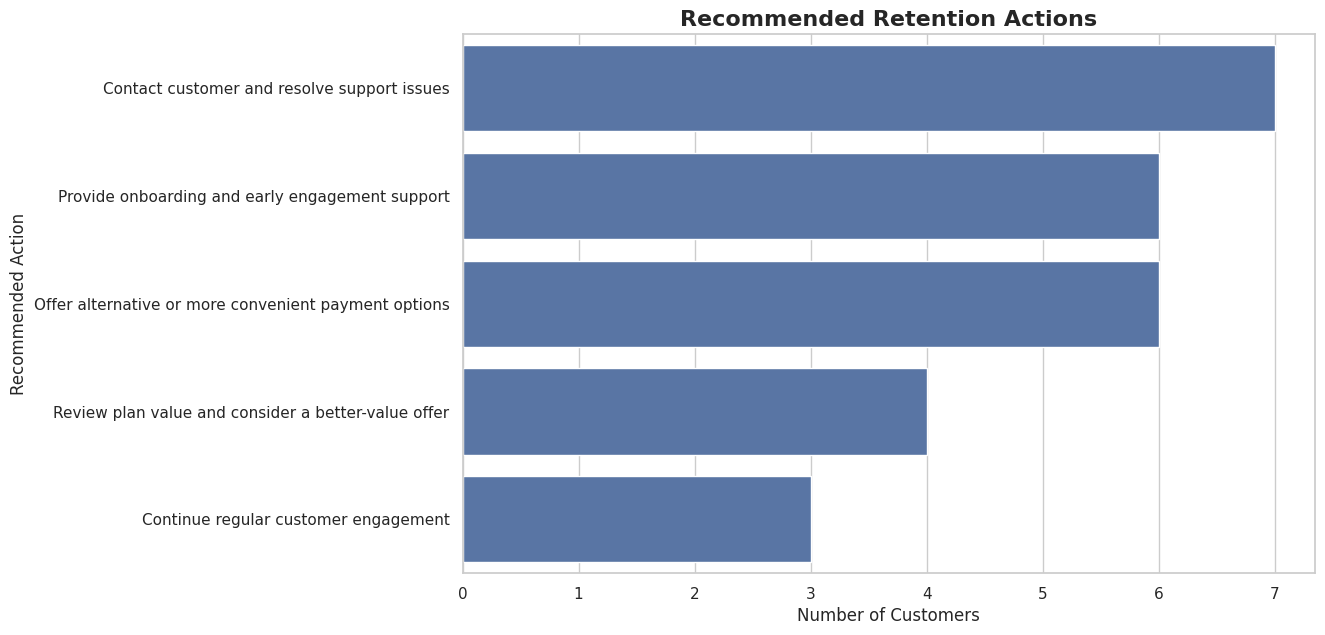

In [33]:
plt.figure(figsize=(11, 7))

sns.barplot(
    x=recommendation_summary.values,
    y=recommendation_summary.index
)

plt.title(
    "Recommended Retention Actions",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Number of Customers")
plt.ylabel("Recommended Action")

plt.show()

In [34]:
journey_summary = df.groupby(
    "TenureGroup",
    observed=False
).agg(
    Customers=("CustomerID", "count"),
    ChurnRate=("Churn", lambda x: (x == "Yes").mean() * 100),
    AvgRisk=("RiskScore", "mean"),
    Revenue=("MonthlyCharges", "sum")
)

journey_summary.round(2)

,Customers,ChurnRate,AvgRisk,Revenue
TenureGroup,,,,
0-12 months,6,100.0,8.67,329.94
13-24 months,5,20.0,2.40,339.95
25-36 months,2,0.0,1.00,299.98
37+ months,2,0.0,1.00,299.98


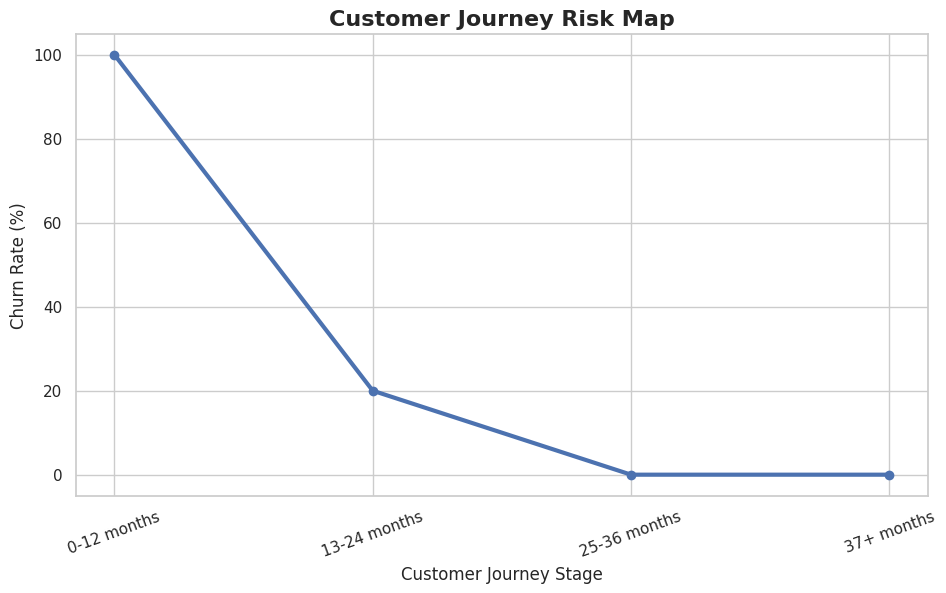

In [35]:
fig, ax1 = plt.subplots(figsize=(11, 6))

ax1.plot(
    journey_summary.index.astype(str),
    journey_summary["ChurnRate"],
    marker="o",
    linewidth=3,
    label="Churn Rate"
)

ax1.set_xlabel("Customer Journey Stage")
ax1.set_ylabel("Churn Rate (%)")

ax1.set_title(
    "Customer Journey Risk Map",
    fontsize=16,
    fontweight="bold"
)

plt.xticks(rotation=20)

plt.show()

In [36]:
decision_framework = pd.DataFrame({
    "Customer Condition": [
        "High Risk + High Monthly Charges",
        "High Risk + Lower Monthly Charges",
        "Medium Risk",
        "Low Risk"
    ],

    "Priority": [
        "Critical",
        "High",
        "Medium",
        "Normal"
    ],

    "Recommended Action": [
        "Immediate personalized retention intervention",
        "Targeted retention campaign",
        "Proactive engagement and monitoring",
        "Maintain regular customer engagement"
    ]
})

decision_framework

,Customer Condition,Priority,Recommended Action
0,High Risk + High Monthly Charges,Critical,Immediate personalized retention intervention
1,High Risk + Lower Monthly Charges,High,Targeted retention campaign
2,Medium Risk,Medium,Proactive engagement and monitoring
3,Low Risk,Normal,Maintain regular customer engagement


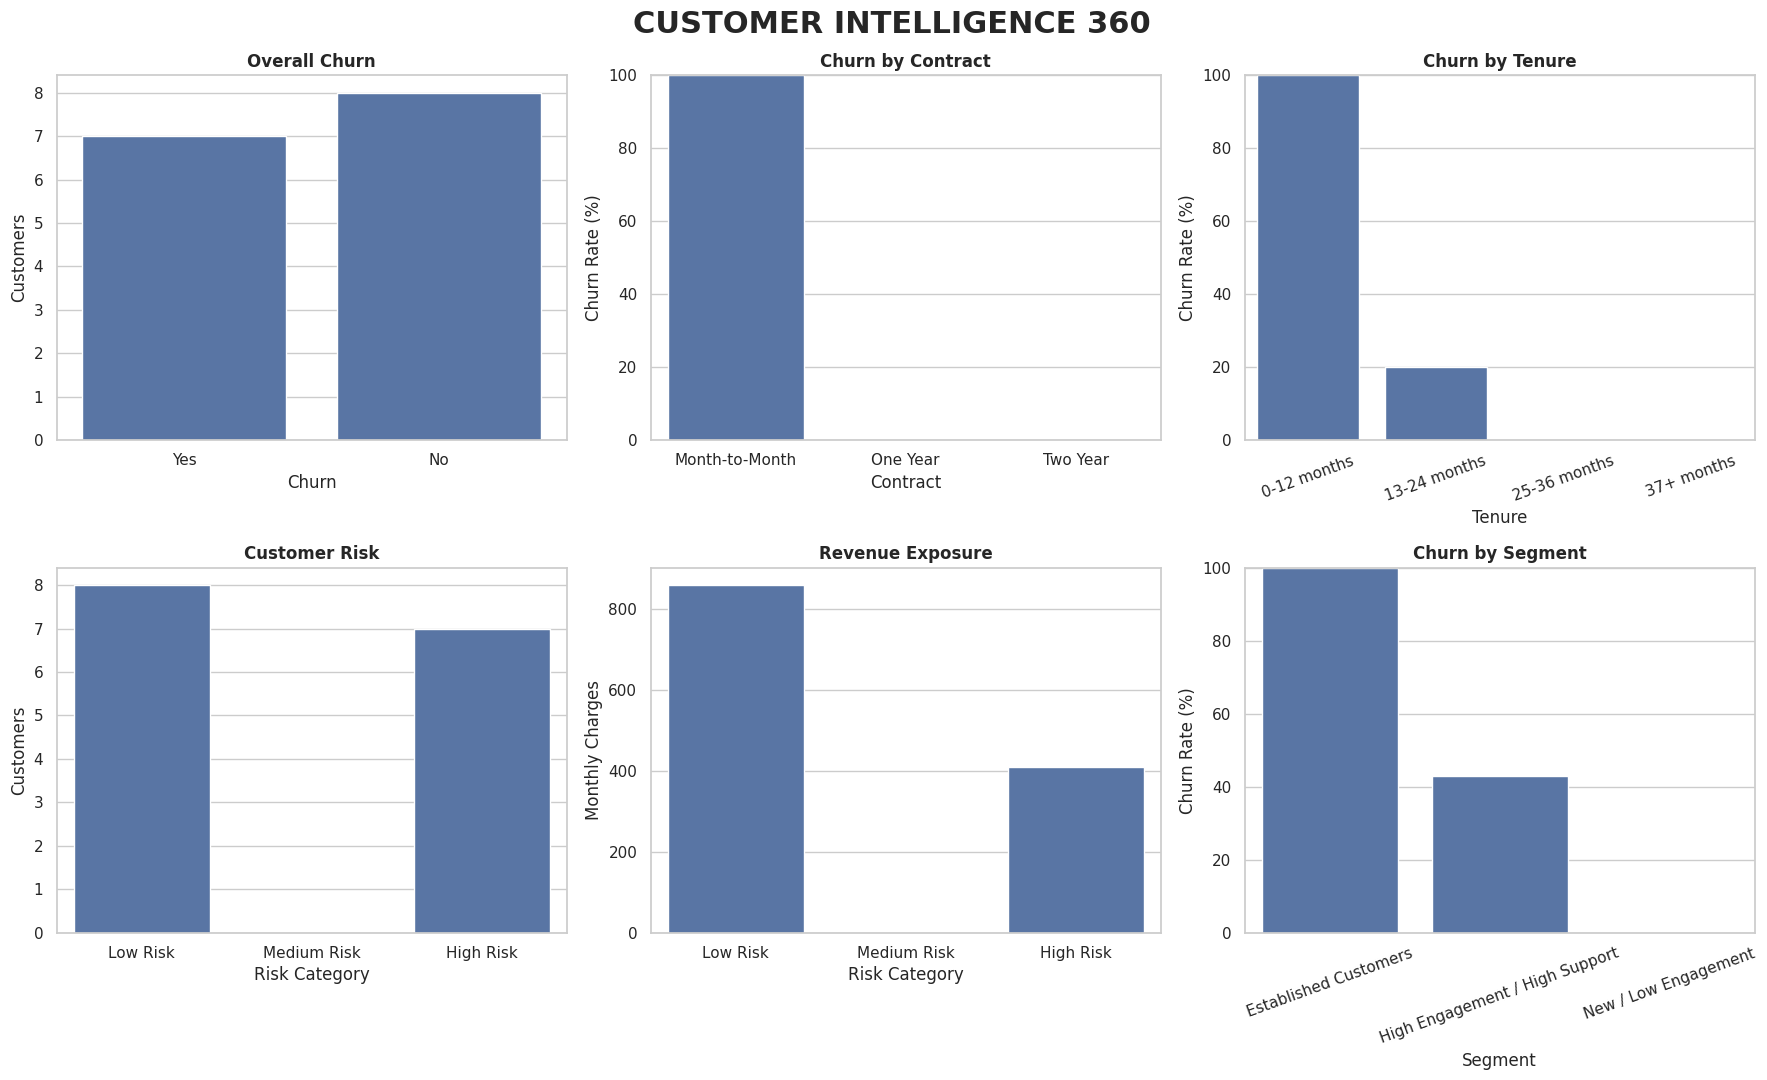

In [37]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(18, 11)
)

# --------------------------------
# 1. Churn
# --------------------------------

sns.countplot(
    data=df,
    x="Churn",
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Overall Churn",
    fontweight="bold"
)

axes[0, 0].set_xlabel("Churn")
axes[0, 0].set_ylabel("Customers")


# --------------------------------
# 2. Contract
# --------------------------------

sns.barplot(
    x=contract_churn.index,
    y=contract_churn.values,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Churn by Contract",
    fontweight="bold"
)

axes[0, 1].set_ylabel("Churn Rate (%)")
axes[0, 1].set_xlabel("Contract")

axes[0, 1].set_ylim(0, 100)


# --------------------------------
# 3. Tenure
# --------------------------------

sns.barplot(
    x=tenure_churn.index,
    y=tenure_churn.values,
    ax=axes[0, 2]
)

axes[0, 2].set_title(
    "Churn by Tenure",
    fontweight="bold"
)

axes[0, 2].set_ylabel("Churn Rate (%)")
axes[0, 2].set_xlabel("Tenure")

axes[0, 2].tick_params(
    axis="x",
    rotation=20
)

axes[0, 2].set_ylim(0, 100)


# --------------------------------
# 4. Risk
# --------------------------------

sns.countplot(
    data=df,
    x="RiskCategory",
    order=[
        "Low Risk",
        "Medium Risk",
        "High Risk"
    ],
    ax=axes[1, 0]
)

axes[1, 0].set_title(
    "Customer Risk",
    fontweight="bold"
)

axes[1, 0].set_xlabel("Risk Category")
axes[1, 0].set_ylabel("Customers")


# --------------------------------
# 5. Revenue Exposure
# --------------------------------

sns.barplot(
    x=revenue_by_risk.index
    if "revenue_by_risk" in globals()
    else risk_summary.index,

    y=revenue_by_risk.values
    if "revenue_by_risk" in globals()
    else risk_summary["MonthlyRevenue"].values,

    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Revenue Exposure",
    fontweight="bold"
)

axes[1, 1].set_xlabel("Risk Category")
axes[1, 1].set_ylabel("Monthly Charges")


# --------------------------------
# 6. Segment Churn
# --------------------------------

segment_churn = (
    df.groupby("SegmentName")["Churn"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

sns.barplot(
    x=segment_churn.index,
    y=segment_churn.values,
    ax=axes[1, 2]
)

axes[1, 2].set_title(
    "Churn by Segment",
    fontweight="bold"
)

axes[1, 2].set_xlabel("Segment")
axes[1, 2].set_ylabel("Churn Rate (%)")

axes[1, 2].tick_params(
    axis="x",
    rotation=20
)

axes[1, 2].set_ylim(0, 100)


plt.suptitle(
    "CUSTOMER INTELLIGENCE 360",
    fontsize=22,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

In [38]:
highest_contract = contract_churn.idxmax()
highest_contract_rate = contract_churn.max()

highest_payment = payment_churn.idxmax()
highest_payment_rate = payment_churn.max()

highest_tenure = tenure_churn.idxmax()
highest_tenure_rate = tenure_churn.max()

highest_segment = segment_churn.idxmax()
highest_segment_rate = segment_churn.max()

print("=" * 70)
print("AUTOMATED EXECUTIVE FINDINGS")
print("=" * 70)

print(
    f"\n1. Overall churn rate: "
    f"{churn_rate:.2f}%"
)

print(
    f"\n2. Monthly revenue at risk: "
    f"{revenue_at_risk:,.2f}"
)

print(
    f"\n3. Contract with highest observed churn: "
    f"{highest_contract} ({highest_contract_rate:.2f}%)"
)

print(
    f"\n4. Payment method with highest observed churn: "
    f"{highest_payment} ({highest_payment_rate:.2f}%)"
)

print(
    f"\n5. Tenure group with highest observed churn: "
    f"{highest_tenure} ({highest_tenure_rate:.2f}%)"
)

print(
    f"\n6. Segment with highest observed churn: "
    f"{highest_segment} ({highest_segment_rate:.2f}%)"
)

print(
    f"\n7. Number of high-risk customers: "
    f"{high_risk_customers}"
)

AUTOMATED EXECUTIVE FINDINGS

1. Overall churn rate: 46.67%

2. Monthly revenue at risk: 409.93

3. Contract with highest observed churn: Month-to-Month (100.00%)

4. Payment method with highest observed churn: Debit Card (100.00%)

5. Tenure group with highest observed churn: 0-12 months (100.00%)

6. Segment with highest observed churn: Established Customers (100.00%)

7. Number of high-risk customers: 7


# FINAL EXECUTIVE RECOMMENDATIONS

## 🎯 Recommendation 1 — Focus on High-Risk Customers

Customers classified as High Risk should be prioritized for
retention intervention.

The business should combine risk level with monthly customer value
when deciding which customers to contact first.

---

## 🎯 Recommendation 2 — Strengthen Early Customer Engagement

If short-tenure customers show elevated churn, the organization
should strengthen:

- Onboarding
- First-month engagement
- Product education
- Early support
- Customer feedback collection

---

## 🎯 Recommendation 3 — Investigate Month-to-Month Customers

If month-to-month customers demonstrate higher churn, the business
could test:

- Long-term contract incentives
- Loyalty benefits
- Personalized offers
- Contract conversion campaigns

---

## 🎯 Recommendation 4 — Resolve Repeated Support Issues

Customers generating multiple support tickets may require
proactive service intervention.

The organization should investigate whether recurring support
issues are related to customer dissatisfaction.

---

## 🎯 Recommendation 5 — Protect High-Value Customers

Customers with:

**High Risk + High Monthly Charges**

should receive priority because losing these customers may create
greater revenue exposure.

---

## 🎯 Recommendation 6 — Use Segmentation for Personalization

Different customer segments should not receive identical retention
campaigns.

Retention strategies should be adapted according to:

- Customer tenure
- Spending
- Support activity
- Contract
- Risk level

---

## 🎯 Recommendation 7 — Move Toward Predictive Analytics

The current project uses an explainable rule-based risk framework.

With a larger historical dataset, the organization could develop
validated machine-learning models such as:

- Logistic Regression
- Decision Trees
- Random Forest
- Gradient Boosting

Model performance should be evaluated using appropriate metrics
before production deployment.

# CAPSTONE CONCLUSION

## Customer Intelligence 360

This project demonstrates a complete customer analytics workflow.

The analysis progressed through four major stages:

### Stage 1 — Understand the Data

The customer dataset was validated for:

- Missing values
- Duplicate records
- Data consistency
- Numerical distributions
- Customer characteristics

### Stage 2 — Understand the Business

Key performance indicators were calculated to understand:

- Customer count
- Churn
- Retention
- Monthly revenue
- Revenue at risk

### Stage 3 — Understand Customer Risk

Customers were analyzed using:

- Churn drivers
- Customer segments
- Risk scores
- Risk categories
- Customer-level risk factors

### Stage 4 — Take Action

The analysis was converted into:

- Retention priorities
- Revenue exposure analysis
- Customer recommendations
- Executive decision framework

---

# Final Analytics Flow

**DATA**

↓  

**DATA QUALITY**

↓  

**CUSTOMER BEHAVIOUR**

↓  

**BUSINESS KPIs**

↓  

**CHURN DRIVERS**

↓  

**CUSTOMER SEGMENTS**

↓  

**RISK SCORING**

↓  

**REVENUE EXPOSURE**

↓  

**RETENTION PRIORITY**

↓  

**EXECUTIVE DECISIONS**

---

## Final Business Message

The key objective of customer analytics is not simply to determine
who has churned.

The objective is to understand:

**WHO is at risk → WHY they are at risk → HOW valuable they are →
WHAT action should be taken.**

This capstone demonstrates that complete analytical workflow.

---

## Dataset Limitation

The dataset used in this project is small and synthetic.

Therefore, the identified relationships and risk scores should be
considered exploratory and demonstrative.

A larger real-world dataset would be required for statistical
validation and production deployment.

In [39]:
df.to_csv(
    "customer_intelligence_360_final.csv",
    index=False
)

print(
    "Final Customer Intelligence 360 dataset exported successfully."
)

Final Customer Intelligence 360 dataset exported successfully.


In [40]:
files.download(
    "customer_intelligence_360_final.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>